<a href="https://colab.research.google.com/github/pankajlp/AutoML/blob/main/telco_automl_loop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔄 AutoML Experimentation Loop — Telco Churn

**Goal:** Iteratively improve AUC-ROC through automated:
- Feature selection (drop redundant/low-importance features)
- Feature engineering (derived features, interactions, melt/reshape)
- Hyperparameter tuning (Optuna) per model per iteration
- Convergence detection (stop when AUC stops improving)

**Models:** Random Forest · XGBoost · LightGBM · CatBoost  
**Metric:** AUC-ROC (StratifiedKFold CV, k=5)  
**Anti-cheat rules:** No target leakage · Correlation pruning before FE · Importance-based selection only on train fold

## 1. Imports & Config

In [2]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.0 MB/s eta 0:00:00


In [3]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [20]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from copy import deepcopy

# ── Config ────────────────────────────────────────────────
TARGET         = 'Churn'
MAX_ITER       = 6          # max experimentation iterations
PATIENCE       = 2          # stop if no improvement for N iters
CV_FOLDS       = 5
OPTUNA_TRIALS  = 30         # trials per model per iteration
CORR_THRESHOLD = 0.90       # drop one of a correlated pair above this
IMP_PERCENTILE = 20         # drop features below this importance percentile
RANDOM_STATE   = 42

print('✅ Imports OK')

✅ Imports OK


## 2. Load & Inspect Dataset

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
df_raw = pd.read_csv('/content/drive/MyDrive/ds_pankaj/csv_files/telco.csv')
print(f'Shape: {df_raw.shape}')
print(f'Target distribution:\n{df_raw[TARGET].value_counts(normalize=True).round(3)}')
df_raw.head(3)

Shape: (7043, 21)
Target distribution:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 3. Preprocessing Utilities

In [12]:
def basic_preprocess(df: pd.DataFrame, target: str) -> pd.DataFrame:
    """Drop ID cols, encode categoricals, return clean numeric DataFrame."""
    df = df.copy()
    # Drop ID / near-unique columns
    id_cols = [c for c in df.columns if df[c].nunique() > 0.9 * len(df) and c != target]
    df.drop(columns=id_cols, inplace=True)
    # Encode binary/ordinal categoricals
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    for col in cat_cols:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    # TotalCharges may have spaces
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df.fillna(df.median(numeric_only=True), inplace=True)
    return df


def remove_correlated(df: pd.DataFrame, target: str, threshold: float) -> pd.DataFrame:
    """Remove one feature from each highly-correlated pair (keep higher target corr)."""
    features = [c for c in df.columns if c != target]
    corr = df[features].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = set()
    for col in upper.columns:
        if col in to_drop:
            continue
        correlated_with = upper.index[upper[col] > threshold].tolist()
        for partner in correlated_with:
            if partner in to_drop:
                continue
            # Keep whichever has higher absolute correlation with target
            tc = df[[col, partner, target]].corr()[target].abs()
            drop_col = partner if tc[col] >= tc[partner] else col
            to_drop.add(drop_col)
    if to_drop:
        print(f'  🔗 Corr pruning dropped: {to_drop}')
    return df.drop(columns=list(to_drop))


def drop_low_importance(df: pd.DataFrame, target: str, percentile: int) -> pd.DataFrame:
    """Use a quick RF to drop features below importance percentile."""
    X = df.drop(columns=[target])
    y = df[target]
    rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=X.columns)
    threshold = np.percentile(importances, percentile)
    low_imp = importances[importances < threshold].index.tolist()
    if low_imp:
        print(f'  🗑️  Importance pruning dropped: {low_imp}')
    return df.drop(columns=low_imp), importances


print('✅ Preprocessing utilities defined')

✅ Preprocessing utilities defined


## 4. Feature Engineering Utilities

In [13]:
def engineer_features(df: pd.DataFrame, iteration: int) -> pd.DataFrame:
    """
    Progressively add features per iteration.
    Each iteration layer adds new derivations without duplicating.
    Anti-cheat: only arithmetic/logical derivations from existing features.
    """
    df = df.copy()
    existing = set(df.columns)

    if iteration >= 1 and 'tenure' in df.columns and 'MonthlyCharges' in df.columns:
        # Spend efficiency
        if 'total_estimated_spend' not in existing:
            df['total_estimated_spend'] = df['tenure'] * df['MonthlyCharges']
        if 'charge_per_tenure' not in existing:
            df['charge_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

    if iteration >= 2 and 'tenure' in df.columns:
        # Tenure buckets via melt-style feature
        if 'tenure_band' not in existing:
            df['tenure_band'] = pd.cut(df['tenure'], bins=[0,12,24,48,72],
                                        labels=[0,1,2,3], right=False).astype(float)
        # Service count (melt many binary cols into aggregate)
        service_cols = [c for c in df.columns if c in [
            'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
            'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']]
        if service_cols and 'service_count' not in existing:
            df['service_count'] = df[service_cols].apply(
                lambda row: (row == row.mode()[0]).sum(), axis=1
            )

    if iteration >= 3 and 'MonthlyCharges' in df.columns and 'TotalCharges' in df.columns:
        # Charge delta (signals tenure vs billing inconsistency)
        if 'charge_delta' not in existing:
            df['charge_delta'] = df['TotalCharges'] - df['total_estimated_spend'] \
                if 'total_estimated_spend' in df.columns \
                else df['TotalCharges'] - (df['tenure'] * df['MonthlyCharges'])
        # High charge flag
        if 'high_monthly' not in existing:
            df['high_monthly'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

    if iteration >= 4:
        # Interaction: senior + high charges
        if 'SeniorCitizen' in df.columns and 'high_monthly' in df.columns:
            if 'senior_high_charge' not in existing:
                df['senior_high_charge'] = df['SeniorCitizen'] * df['high_monthly']
        # Short tenure + month-to-month proxy
        if 'tenure' in df.columns and 'Contract' in df.columns:
            if 'risky_segment' not in existing:
                df['risky_segment'] = ((df['tenure'] < 12) & (df['Contract'] == 0)).astype(int)

    new_feats = [c for c in df.columns if c not in existing]
    if new_feats:
        print(f'  ✨ New features added: {new_feats}')
    return df


print('✅ Feature engineering utilities defined')

✅ Feature engineering utilities defined


## 5. Optuna Hyperparameter Tuning

In [14]:
def tune_model(model_name: str, X: pd.DataFrame, y: pd.Series, n_trials: int) -> dict:
    """Run Optuna tuning for given model. Returns best params."""
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial):
        if model_name == 'RandomForest':
            params = dict(
                n_estimators     = trial.suggest_int('n_estimators', 100, 600, step=100),
                max_depth        = trial.suggest_int('max_depth', 3, 20),
                min_samples_split= trial.suggest_int('min_samples_split', 2, 20),
                min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10),
                max_features     = trial.suggest_categorical('max_features', ['sqrt','log2', 0.5]),
                random_state     = RANDOM_STATE, n_jobs=-1
            )
            model = RandomForestClassifier(**params)

        elif model_name == 'XGBoost':
            params = dict(
                n_estimators     = trial.suggest_int('n_estimators', 100, 600, step=100),
                max_depth        = trial.suggest_int('max_depth', 3, 10),
                learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample        = trial.suggest_float('subsample', 0.5, 1.0),
                colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
                gamma            = trial.suggest_float('gamma', 0, 5),
                reg_alpha        = trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
                reg_lambda       = trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
                use_label_encoder= False, eval_metric='auc',
                random_state     = RANDOM_STATE, n_jobs=-1
            )
            model = xgb.XGBClassifier(**params)

        elif model_name == 'LightGBM':
            params = dict(
                n_estimators     = trial.suggest_int('n_estimators', 100, 600, step=100),
                max_depth        = trial.suggest_int('max_depth', 3, 12),
                learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                num_leaves       = trial.suggest_int('num_leaves', 20, 150),
                subsample        = trial.suggest_float('subsample', 0.5, 1.0),
                colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
                reg_alpha        = trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
                reg_lambda       = trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
                random_state     = RANDOM_STATE, n_jobs=-1, verbose=-1
            )
            model = lgb.LGBMClassifier(**params)

        elif model_name == 'CatBoost':
            params = dict(
                iterations       = trial.suggest_int('iterations', 100, 600, step=100),
                depth            = trial.suggest_int('depth', 3, 10),
                learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                l2_leaf_reg      = trial.suggest_float('l2_leaf_reg', 1e-8, 10, log=True),
                random_seed      = RANDOM_STATE, verbose=0
            )
            model = cb.CatBoostClassifier(**params)

        scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params, study.best_value


print('✅ Optuna tuning defined')

✅ Optuna tuning defined


## 6. Main Experimentation Loop

In [15]:
MODEL_NAMES = ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']

# ── State tracking ────────────────────────────────────────
history = []          # list of dicts: {iter, model, auc, n_features, params}
best_overall = {'auc': 0, 'model': None, 'params': None, 'features': None, 'iter': -1}
no_improve_count = 0
prev_best_auc = 0

# ── Initial preprocessing (done once) ─────────────────────
df_clean = basic_preprocess(df_raw, TARGET)
print(f'After basic preprocessing: {df_clean.shape}')

df_current = df_clean.copy()

# ── Loop ──────────────────────────────────────────────────
for iteration in range(MAX_ITER):
    print(f'\n{"="*60}')
    print(f'🔄 ITERATION {iteration} | Features: {df_current.shape[1]-1}')
    print(f'{"="*60}')

    df_iter = df_current.copy()

    # Step 1: Feature Engineering
    print('\n📐 Feature Engineering...')
    df_iter = engineer_features(df_iter, iteration)

    # Step 2: Correlation pruning (anti-redundancy)
    print('\n🔗 Removing correlated features...')
    df_iter = remove_correlated(df_iter, TARGET, CORR_THRESHOLD)

    # Step 3: Importance-based pruning (only from iter 1+)
    importances = None
    if iteration >= 1:
        print('\n📊 Importance-based pruning...')
        df_iter, importances = drop_low_importance(df_iter, TARGET, IMP_PERCENTILE)

    X = df_iter.drop(columns=[TARGET])
    y = df_iter[TARGET]
    print(f'\n✅ Final feature set ({len(X.columns)}): {X.columns.tolist()}')

    # Step 4: Tune & evaluate all models
    iter_best_auc = 0
    iter_best_model = None
    iter_best_params = None

    for model_name in MODEL_NAMES:
        print(f'\n  🤖 Tuning {model_name} ({OPTUNA_TRIALS} trials)...')
        best_params, best_auc = tune_model(model_name, X, y, OPTUNA_TRIALS)
        print(f'     AUC: {best_auc:.5f} | Best params: {best_params}')

        history.append({
            'iteration': iteration,
            'model': model_name,
            'auc': best_auc,
            'n_features': len(X.columns),
            'features': X.columns.tolist(),
            'params': best_params
        })

        if best_auc > iter_best_auc:
            iter_best_auc = best_auc
            iter_best_model = model_name
            iter_best_params = best_params

        if best_auc > best_overall['auc']:
            best_overall.update({
                'auc': best_auc,
                'model': model_name,
                'params': best_params,
                'features': X.columns.tolist(),
                'iter': iteration
            })

    print(f'\n🏆 Iter {iteration} best: {iter_best_model} | AUC = {iter_best_auc:.5f}')

    # Step 5: Convergence check
    if iter_best_auc > prev_best_auc + 0.0005:  # min meaningful improvement
        print(f'  📈 Improved by {iter_best_auc - prev_best_auc:.5f} — continuing')
        no_improve_count = 0
        prev_best_auc = iter_best_auc
        df_current = df_iter.copy()  # commit this feature set
    else:
        no_improve_count += 1
        print(f'  📉 No meaningful improvement ({no_improve_count}/{PATIENCE}) — reverting feature set')
        if no_improve_count >= PATIENCE:
            print('\n⛔ Convergence reached — stopping loop')
            break

print(f'\n✅ Loop complete')

After basic preprocessing: (7043, 19)

🔄 ITERATION 0 | Features: 18

📐 Feature Engineering...

🔗 Removing correlated features...

✅ Final feature set (18): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges']

  🤖 Tuning RandomForest (30 trials)...
     AUC: 0.84489 | Best params: {'n_estimators': 100, 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt'}

  🤖 Tuning XGBoost (30 trials)...
     AUC: 0.84859 | Best params: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.014897607426124, 'subsample': 0.6226784022364871, 'colsample_bytree': 0.5567108683881764, 'gamma': 4.388699458473195, 'reg_alpha': 0.09826812082549333, 'reg_lambda': 0.20230826246821546}

  🤖 Tuning LightGBM (30 trials)...
     AUC: 0.84671 | Best para

## 7. Results Summary

In [16]:
results_df = pd.DataFrame(history)

print('=' * 60)
print('🏆 BEST OVERALL RESULT')
print('=' * 60)
print(f"  Model      : {best_overall['model']}")
print(f"  AUC-ROC    : {best_overall['auc']:.5f}")
print(f"  Iteration  : {best_overall['iter']}")
print(f"  Features   : {best_overall['features']}")
print(f"  Params     : {best_overall['params']}")

print('\n📊 AUC per model per iteration:')
pivot = results_df.pivot_table(index='iteration', columns='model', values='auc', aggfunc='max')
print(pivot.round(5))

🏆 BEST OVERALL RESULT
  Model      : CatBoost
  AUC-ROC    : 0.84905
  Iteration  : 1
  Features   : ['gender', 'SeniorCitizen', 'Partner', 'tenure', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'total_estimated_spend', 'charge_per_tenure']
  Params     : {'iterations': 600, 'depth': 3, 'learning_rate': 0.015676803768757318, 'l2_leaf_reg': 0.11560042654362822}

📊 AUC per model per iteration:
model      CatBoost  LightGBM  RandomForest  XGBoost
iteration                                           
0           0.84885   0.84671       0.84489  0.84859
1           0.84905   0.84666       0.84475  0.84859
2           0.84902   0.84704       0.84397  0.84825


## 8. AUC Progression Charts

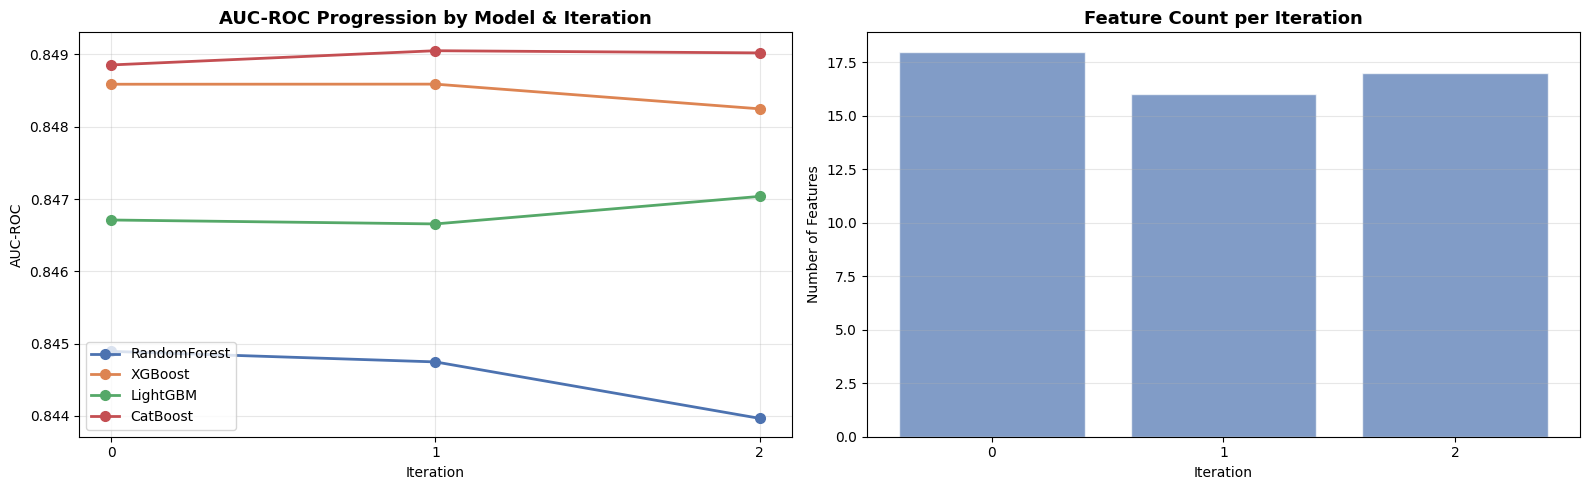

✅ Charts saved to auc_progression.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Plot 1: AUC per model per iteration ───────────────────
ax = axes[0]
colors = {'RandomForest': '#4C72B0', 'XGBoost': '#DD8452',
          'LightGBM': '#55A868', 'CatBoost': '#C44E52'}
for model_name in MODEL_NAMES:
    subset = results_df[results_df['model'] == model_name]
    ax.plot(subset['iteration'], subset['auc'], marker='o',
            label=model_name, color=colors[model_name], linewidth=2, markersize=7)

ax.set_title('AUC-ROC Progression by Model & Iteration', fontsize=13, fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('AUC-ROC')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(results_df['iteration'].unique())

# ── Plot 2: Feature count per iteration ───────────────────
ax2 = axes[1]
feat_counts = results_df.groupby('iteration')['n_features'].first()
ax2.bar(feat_counts.index, feat_counts.values, color='#4C72B0', alpha=0.7, edgecolor='white')
ax2.set_title('Feature Count per Iteration', fontsize=13, fontweight='bold')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Number of Features')
ax2.set_xticks(feat_counts.index)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('auc_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Charts saved to auc_progression.png')

## 9. Final Model Feature Importance

  ✨ New features added: ['total_estimated_spend', 'charge_per_tenure']


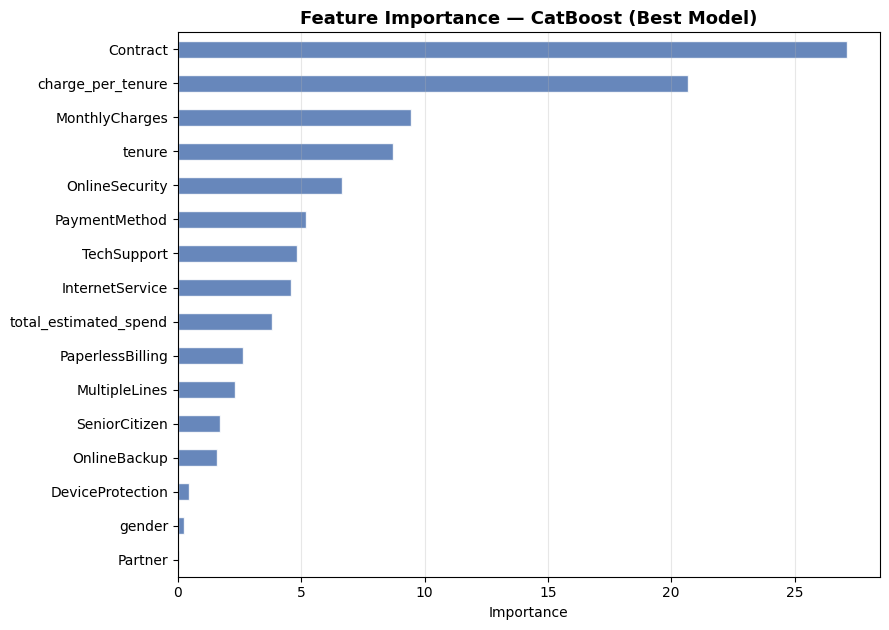

✅ Feature importance saved


In [21]:
# Retrain best model on full data with best params for importance plot

# Reconstruct the feature set corresponding to the best overall model
# Start with the basic preprocessed dataframe
reconstructed_df = df_clean.copy()

# Apply feature engineering up to the iteration where the best model was found.
# The 'engineer_features' function is cumulative, so calling it with best_overall['iter']
# will add all features up to that specific iteration.
reconstructed_df = engineer_features(reconstructed_df, best_overall['iter'])

# The 'best_overall['features']' list already contains the final features
# after all pruning steps (correlation and importance) for that specific iteration.
# So, we can directly select these columns from the reconstructed dataframe.
# This implicitly handles the pruning by only selecting the desired features.
final_features_for_X = [f for f in best_overall['features'] if f != TARGET]

X_final = reconstructed_df[final_features_for_X]
y_final = reconstructed_df[TARGET]

best_model_name = best_overall['model']
best_params     = best_overall['params']

if best_model_name == 'RandomForest':
    final_model = RandomForestClassifier(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
elif best_model_name == 'XGBoost':
    # Ensure use_label_encoder=False and eval_metric='auc' are included as they were in tuning
    final_model = xgb.XGBClassifier(**best_params, use_label_encoder=False, eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1)
elif best_model_name == 'LightGBM':
    # Ensure verbose=-1 is included as it was in tuning
    final_model = lgb.LGBMClassifier(**best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
elif best_model_name == 'CatBoost':
    # Ensure verbose=0 and random_seed are included as they were in tuning
    final_model = cb.CatBoostClassifier(**best_params, random_seed=RANDOM_STATE, verbose=0)

final_model.fit(X_final, y_final)

if hasattr(final_model, 'feature_importances_'):
    imp = pd.Series(final_model.feature_importances_, index=X_final.columns)
    imp = imp.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, max(4, len(imp)*0.4)))
    imp.plot(kind='barh', ax=ax, color='#4C72B0', alpha=0.85, edgecolor='white')
    ax.set_title(f'Feature Importance — {best_model_name} (Best Model)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Feature importance saved')
else:
    print('Feature importance not available for this model type.')

## 10. Full Results Log

In [19]:
display_df = results_df[['iteration','model','auc','n_features']].copy()
display_df['auc'] = display_df['auc'].round(5)
display_df = display_df.sort_values(['iteration','auc'], ascending=[True, False])
display_df.style.background_gradient(subset=['auc'], cmap='YlGn').set_caption('Full Experiment Log')

,iteration,model,auc,n_features
3,0,CatBoost,0.848850,18
1,0,XGBoost,0.848590,18
2,0,LightGBM,0.846710,18
0,0,RandomForest,0.844890,18
7,1,CatBoost,0.849050,16
5,1,XGBoost,0.848590,16
6,1,LightGBM,0.846660,16
4,1,RandomForest,0.844750,16
11,2,CatBoost,0.849020,17
9,2,XGBoost,0.848250,17
